**Анализ профессиональных кластеров**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from setuptools.command.rotate import rotate

# Загрузка данных
df = pd.read_csv('data/processed/vacancies_processed.csv')

# Функция для извлечения зарплаты
def extract_salary(row):
    if pd.notna(row['salary_from']) and pd.notna(row['salary_to']):
        return (row['salary_from'] + row['salary_to']) / 2
    elif pd.notna(row['salary_from']):
        return row['salary_from']
    elif pd.notna(row['salary_to']):
        return row['salary_to']
    else:
        return np.nan

df['salary_avg'] = df.apply(extract_salary, axis=1)

# СОЗДАНИЕ ПРОФЕССИОНАЛЬНЫХ КЛАСТЕРОВ
def assign_cluster(role):
    """Распределяет профессиональную роль по кластеру"""
    role_lower = str(role).lower()

    if any(word in role_lower for word in ['программист', 'разработчик', 'devops', 'тестировщик', 'qa', 'архитектор', 'data scientist', 'дата-сайентист']):
        return 'IT-разработка'
    elif any(word in role_lower for word in ['аналитик', 'bi-аналитик', 'data', 'продуктовый аналитик', 'системный аналитик', 'бизнес-аналитик']):
        return 'Аналитика и данные'
    elif any(word in role_lower for word in ['менеджер по продажам', 'продавец', 'работе с клиентами', 'менеджер по работе с клиентами', 'оператор call-центра']):
        return 'Продажи и обслуживание'
    elif any(word in role_lower for word in ['инженер', 'технолог', 'механик', 'электромонтажник', 'слесарь', 'машинист', 'оператор производственной']):
        return 'Инженерия и производство'
    elif any(word in role_lower for word in ['маркетинг', 'pr', 'smm', 'продюсер', 'дизайнер', 'художник']):
        return 'Маркетинг и креатив'
    elif any(word in role_lower for word in ['hr', 'персонал', 'подбор', 'кадры', 'рекрутер']):
        return 'HR и управление персоналом'
    elif any(word in role_lower for word in ['финанс', 'бухгалтер', 'экономист', 'аудитор', 'казначей']):
        return 'Финансы и учет'
    elif any(word in role_lower for word in ['юрист', 'юрисконсульт', 'комплаенс']):
        return 'Юридическая служба'
    elif any(word in role_lower for word in ['администратор', 'секретарь', 'ассистент', 'офис-менеджер', 'делопроизводитель']):
        return 'Административный персонал'
    elif any(word in role_lower for word in ['руководитель', 'директор', 'начальник', 'заведующий']):
        return 'Руководство'
    else:
        return 'Другие'

df['professional_cluster'] = df['professional_role'].apply(assign_cluster)

# Смотрим распределение
print("Распределение вакансий по кластерам:")
print(df['professional_cluster'].value_counts())
print("\nРаспределение по компаниям и кластерам:")
print(pd.crosstab(df['company'], df['professional_cluster']))

Распределение вакансий по кластерам:
professional_cluster
Другие                        540
Продажи и обслуживание        467
Аналитика и данные            246
IT-разработка                 230
Инженерия и производство      215
Финансы и учет                 96
Руководство                    80
Административный персонал      71
Маркетинг и креатив            53
HR и управление персоналом     22
Юридическая служба             19
Name: count, dtype: int64

Распределение по компаниям и кластерам:
professional_cluster  HR и управление персоналом  IT-разработка  \
company                                                           
Газпром нефть                                  6             14   
СБЕР                                          11             92   
Яндекс                                         5            124   

professional_cluster  Административный персонал  Аналитика и данные  Другие  \
company                                                                       
Газпром

Визуализация 1: Тепловая карта кластеров по компаниям

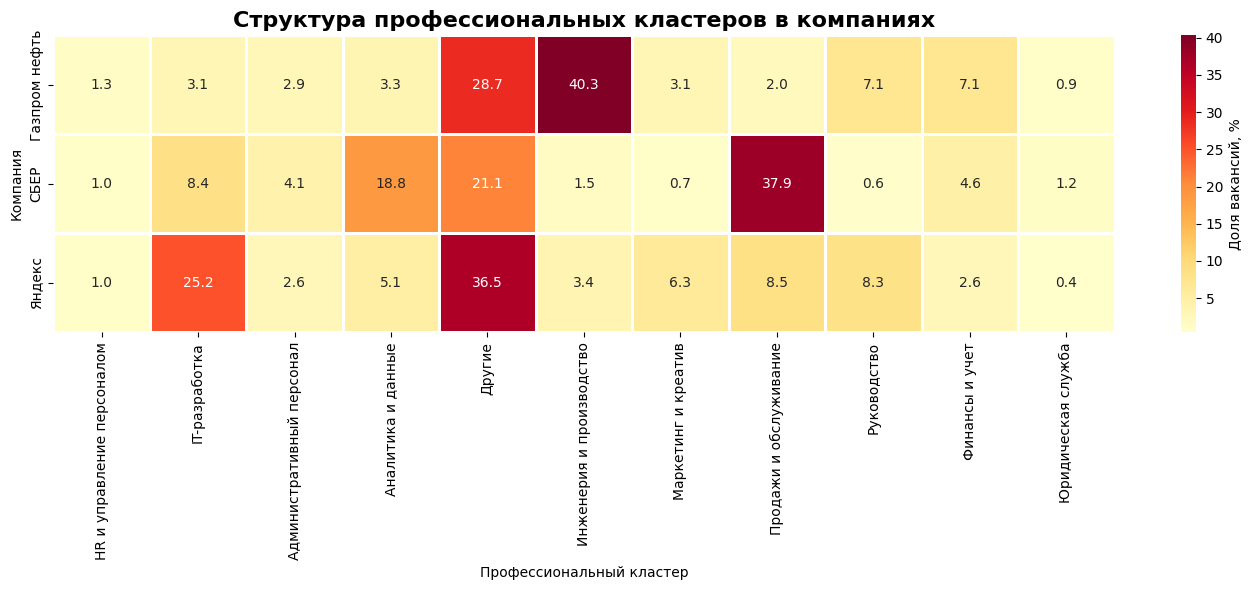

In [7]:
# Создаем сводную таблицу
cluster_pivot = pd.crosstab(
    df['company'],
    df['professional_cluster'],
    normalize='index'
) * 100

# Тепловая карта
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, cbar_kws={'label': 'Доля вакансий, %'})
plt.title('Структура профессиональных кластеров в компаниях', fontsize=16, fontweight='bold')
plt.xlabel('Профессиональный кластер')
plt.ylabel('Компания')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Визуализация 2: Зарплаты по кластерам

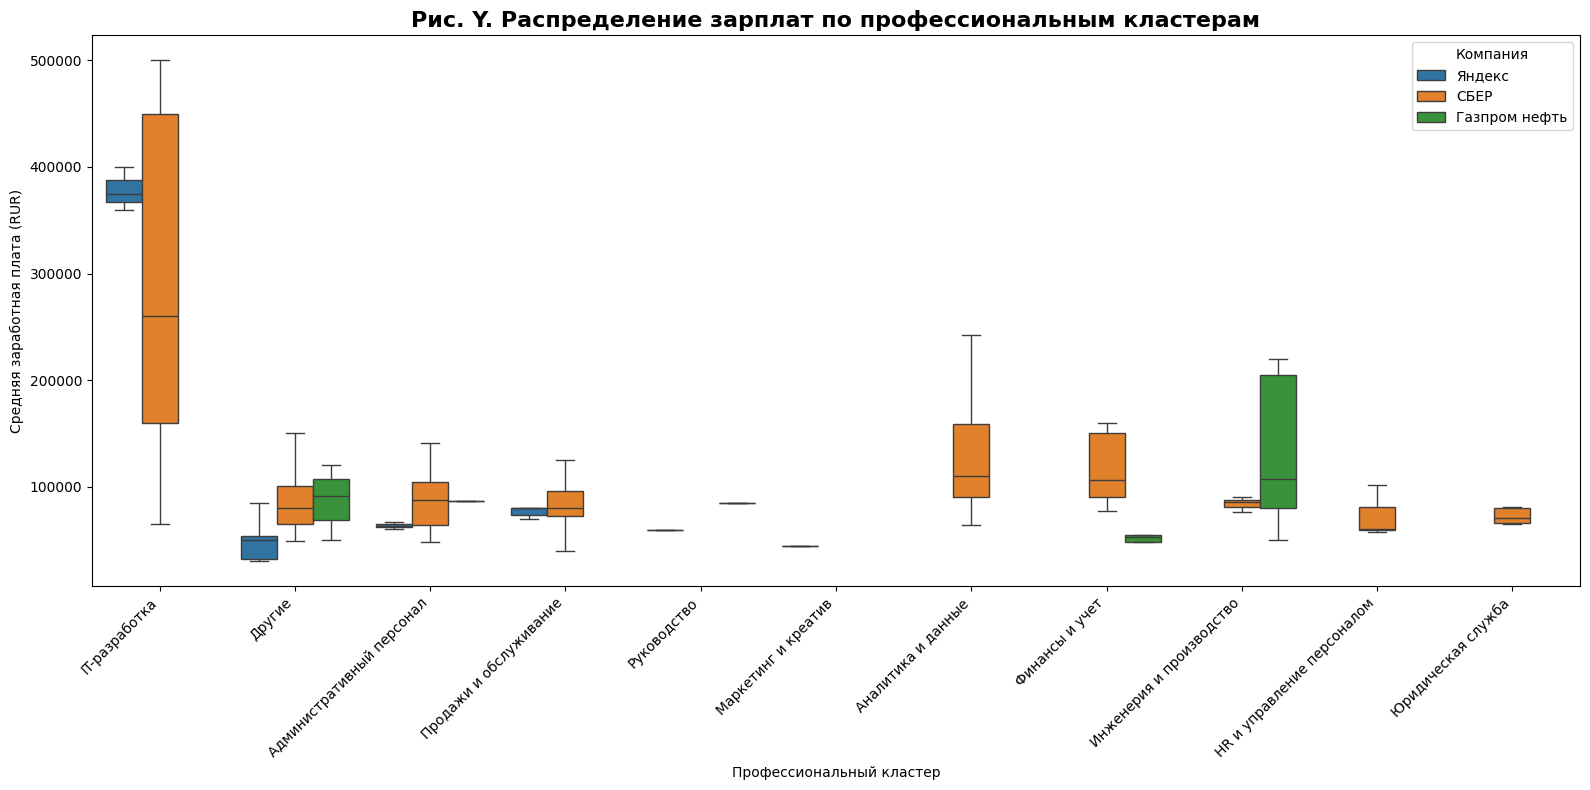

In [3]:
# Убираем вакансии без зарплаты
df_salary = df[df['salary_avg'].notna()].copy()

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=df_salary,
    x='professional_cluster',
    y='salary_avg',
    hue='company',
    showfliers=False
)
plt.title('Рис. Y. Распределение зарплат по профессиональным кластерам', fontsize=16, fontweight='bold')
plt.xlabel('Профессиональный кластер')
plt.ylabel('Средняя заработная плата (RUR)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Компания')
plt.tight_layout()
plt.show()

Визуализация 3: Ключевые бенефиты по кластерам

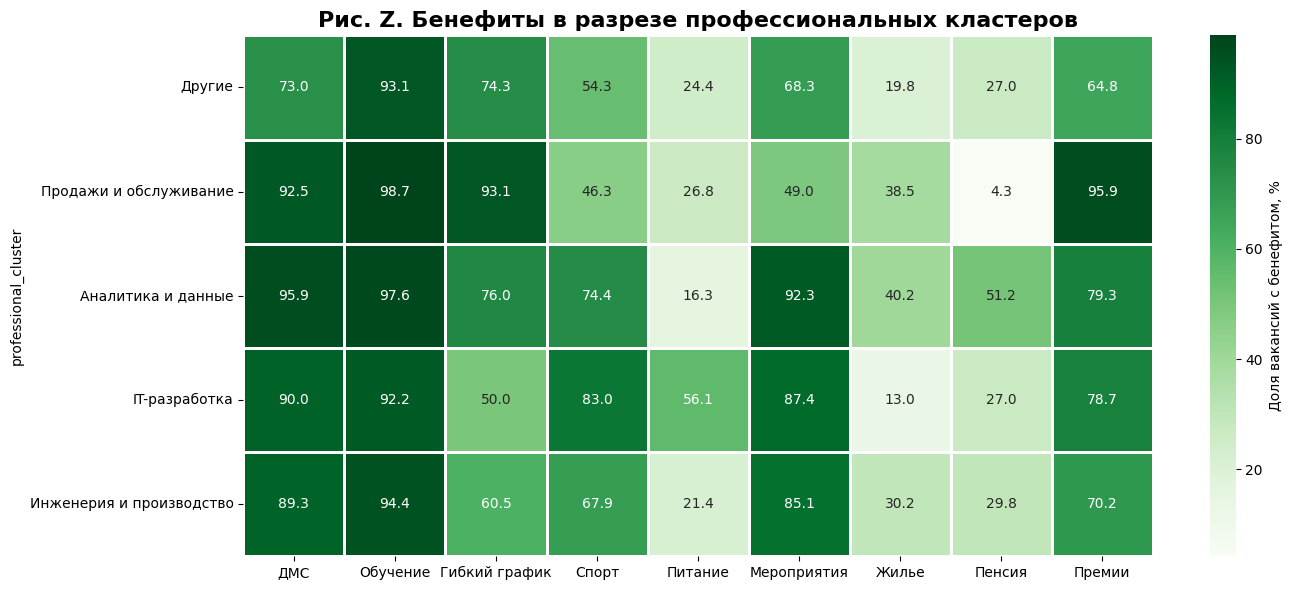

In [4]:
# Список бенефитов
benefit_cols = ['benefit_ДМС', 'benefit_Обучение', 'benefit_Гибкий график',
                'benefit_Спорт', 'benefit_Питание', 'benefit_Ивенты',
                'benefit_Жилищные программы', 'benefit_Пенсия', 'benefit_Премии']

benefit_names = {
    'benefit_ДМС': 'ДМС',
    'benefit_Обучение': 'Обучение',
    'benefit_Гибкий график': 'Гибкий график',
    'benefit_Спорт': 'Спорт',
    'benefit_Питание': 'Питание',
    'benefit_Ивенты': 'Мероприятия',
    'benefit_Жилищные программы': 'Жилье',
    'benefit_Пенсия': 'Пенсия',
    'benefit_Премии': 'Премии'
}

# Для каждого кластера считаем долю бенефитов
cluster_benefits = df.groupby('professional_cluster')[benefit_cols].mean() * 100
cluster_benefits = cluster_benefits.rename(columns=benefit_names)

# Выбираем топ-5 кластеров по количеству вакансий
top_clusters = df['professional_cluster'].value_counts().head(5).index
cluster_benefits_top = cluster_benefits.loc[top_clusters]

# Тепловая карта
plt.figure(figsize=(14, 6))
sns.heatmap(cluster_benefits_top, annot=True, fmt='.1f', cmap='Greens',
            linewidths=1, cbar_kws={'label': 'Доля вакансий с бенефитом, %'})
plt.title('Рис. Z. Бенефиты в разрезе профессиональных кластеров', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Облако тегов для бенефитов**


Облако тегов для Яндекс:


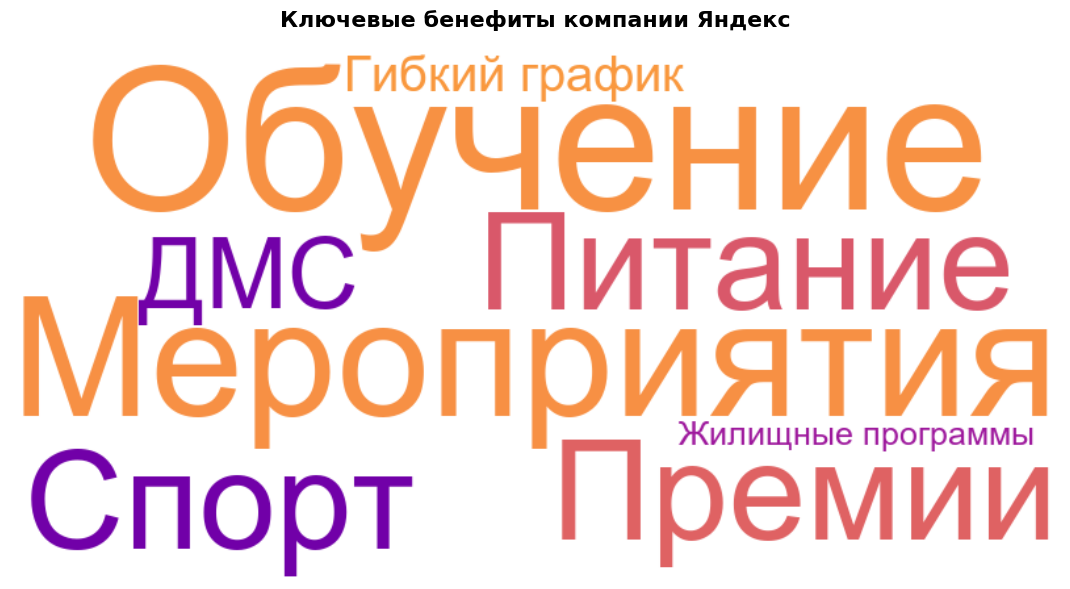

Частота бенефитов: {'ДМС': np.int64(276), 'Обучение': np.int64(418), 'Гибкий график': np.int64(218), 'Спорт': np.int64(320), 'Питание': np.int64(309), 'Мероприятия': np.int64(340), 'Жилищные программы': np.int64(64), 'Премии': np.int64(329)}

Облако тегов для СБЕР:


<Figure size 640x480 with 0 Axes>

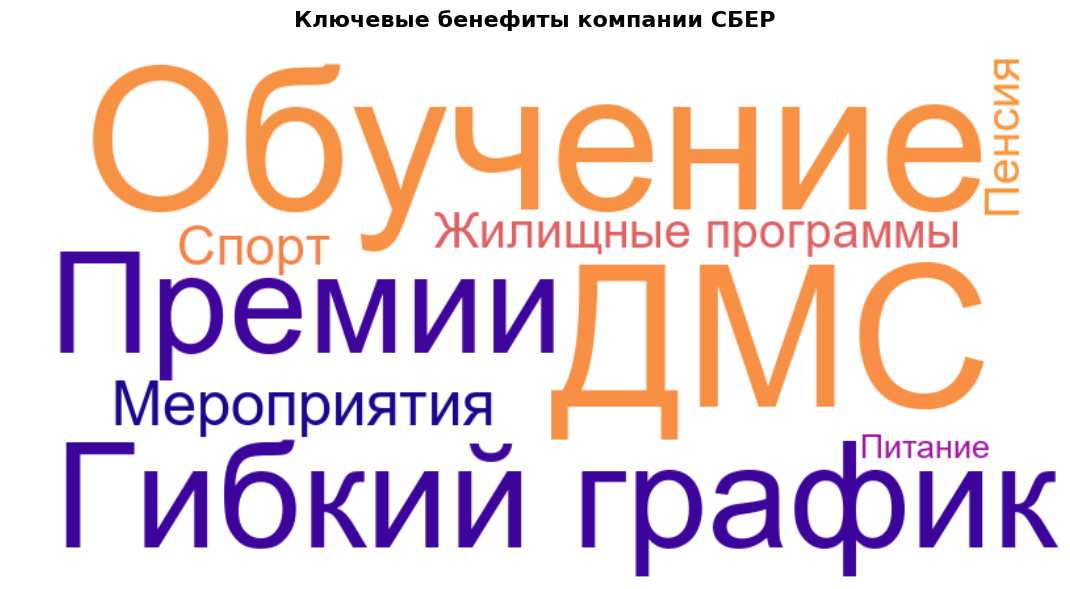

Частота бенефитов: {'ДМС': np.int64(1082), 'Обучение': np.int64(1088), 'Гибкий график': np.int64(1004), 'Спорт': np.int64(577), 'Питание': np.int64(184), 'Мероприятия': np.int64(755), 'Жилищные программы': np.int64(469), 'Пенсия': np.int64(444), 'Премии': np.int64(915)}

Облако тегов для Газпром нефть:


<Figure size 640x480 with 0 Axes>

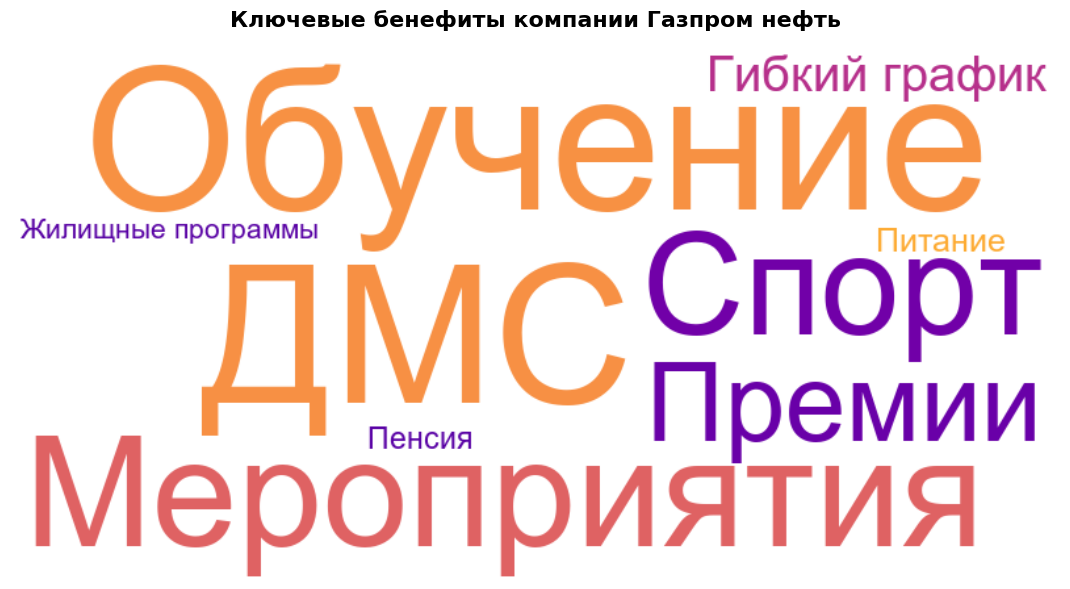

Частота бенефитов: {'ДМС': np.int64(404), 'Обучение': np.int64(419), 'Гибкий график': np.int64(232), 'Спорт': np.int64(341), 'Питание': np.int64(73), 'Мероприятия': np.int64(400), 'Жилищные программы': np.int64(54), 'Пенсия': np.int64(64), 'Премии': np.int64(335)}


<Figure size 640x480 with 0 Axes>

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Подготовка данных для облака тегов
def create_benefit_wordcloud(company_data, company_name):
    """
    Создает облако тегов для бенефитов конкретной компании
    """

    # Список бенефитов и их русские названия
    benefit_cols = ['benefit_ДМС', 'benefit_Обучение', 'benefit_Гибкий график',
                    'benefit_Спорт', 'benefit_Питание', 'benefit_Ивенты',
                    'benefit_Жилищные программы', 'benefit_Пенсия', 'benefit_Премии']

    benefit_names_ru = {
        'benefit_ДМС': 'ДМС',
        'benefit_Обучение': 'Обучение',
        'benefit_Гибкий график': 'Гибкий график',
        'benefit_Спорт': 'Спорт',
        'benefit_Питание': 'Питание',
        'benefit_Ивенты': 'Мероприятия',
        'benefit_Жилищные программы': 'Жилищные программы',
        'benefit_Пенсия': 'Пенсия',
        'benefit_Премии': 'Премии'
    }

    # Считаем частоту каждого бенефита
    benefit_freq = {}
    for col in benefit_cols:
        # Частота = количество вакансий с бенефитом
        freq = company_data[col].sum()
        if freq > 0:
            benefit_freq[benefit_names_ru[col]] = freq

    # Создаем облако тегов
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='plasma',
        prefer_horizontal=0.7,
        min_font_size=10,
        max_font_size=150,
        random_state=42,
        font_path='C:/Windows/Fonts/Arial.ttf'  # Если есть русский шрифт, можно указать путь
    ).generate_from_frequencies(benefit_freq)

    # Визуализация
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Ключевые бенефиты компании {company_name}', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    return benefit_freq

# Создаем облака для каждой компании
for company in df['company'].unique():
    company_data = df[df['company'] == company]
    print(f"\nОблако тегов для {company}:")
    freq_dict = create_benefit_wordcloud(company_data, company)
    print(f"Частота бенефитов: {freq_dict}")

    # Сохраняем облако
    plt.savefig(f'wordcloud_{company}.png', dpi=300, bbox_inches='tight')

Диаграмма радар

In [8]:
import plotly.graph_objects as go

categories = ['Акцент на инновации и технологии',
              'Акцент на стабильность и гарантии',
              'Неформальность и открытость коммуникации',
              'Глубина и экспертность контента',
              'Уровень вовлечённости цифровой аудитории',
              'Прозрачность карьерных возможностей']

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=[5, 2, 4, 5, 1, 4],
    theta=categories,
    fill='toself',
    name='Яндекс',
    line_color='#FF6B6B'
))

fig.add_trace(go.Scatterpolar(
    r=[3, 5, 2, 4, 2, 3],
    theta=categories,
    fill='toself',
    name='Газпром',
    line_color='#4ECDC4'
))

fig.add_trace(go.Scatterpolar(
    r=[4, 3, 5, 3, 3, 2],
    theta=categories,
    fill='toself',
    name='Сбербанк',
    line_color='#45B7D1'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 5]
        )),
    showlegend=True,
    title='Сравнение компаний по ключевым параметрам',
    width=800,
    height=800
)

fig.show()

In [7]:
import plotly.graph_objects as go
import plotly.io as pio

# Устанавливаем рендерер для отображения в Jupyter/браузере
pio.renderers.default = 'browser'  # или 'svg', 'png'

categories = ['Акцент на инновации и технологии',
              'Акцент на стабильность и гарантии',
              'Неформальность и открытость коммуникации',
              'Глубина и экспертность контента',
              'Уровень вовлечённости цифровой аудитории',
              'Прозрачность карьерных возможностей']

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=[5, 2, 4, 5, 1, 4],
    theta=categories,
    fill='toself',
    name='Яндекс',
    line_color='#FF6B6B'
))

fig.add_trace(go.Scatterpolar(
    r=[3, 5, 2, 4, 2, 3],
    theta=categories,
    fill='toself',
    name='Газпром',
    line_color='#4ECDC4'
))

fig.add_trace(go.Scatterpolar(
    r=[4, 3, 5, 3, 3, 2],
    theta=categories,
    fill='toself',
    name='Сбербанк',
    line_color='#45B7D1'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 5]
        )),
    showlegend=True,
    title='Сравнение компаний по ключевым параметрам',
    width=800,
    height=800
)

# Сохраняем как HTML файл
fig.write_html("radar_chart.html")
print("График сохранен как 'radar_chart.html'")

# Если хотите открыть в браузере автоматически
import webbrowser
webbrowser.open("radar_chart.html")

График сохранен как 'radar_chart.html'


True

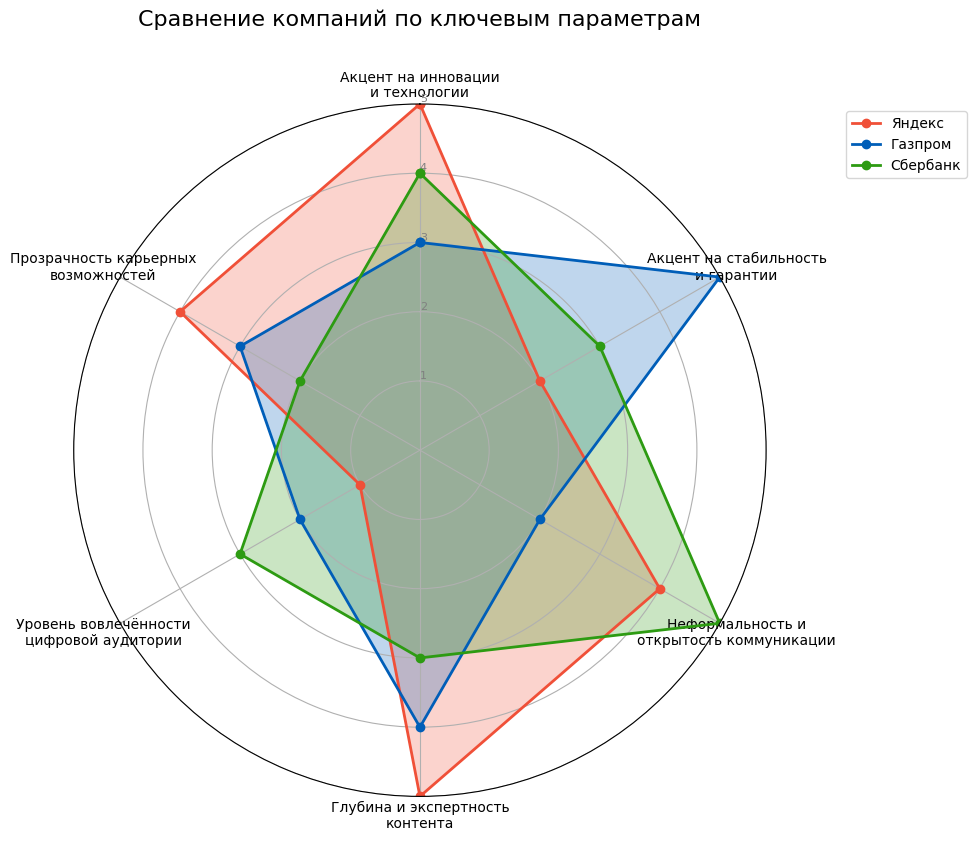

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ваши данные
data = {
    'Яндекс': [5, 2, 4, 5, 1, 4],
    'Газпром': [3, 5, 2, 4, 2, 3],
    'Сбербанк': [4, 3, 5, 3, 3, 2]
}

categories = ['Акцент на инновации\nи технологии',
              'Акцент на стабильность\nи гарантии',
              'Неформальность и\nоткрытость коммуникации',
              'Глубина и экспертность\nконтента',
              'Уровень вовлечённости\nцифровой аудитории',
              'Прозрачность карьерных\nвозможностей']

# Количество переменных
N = len(categories)

# Создаем углы для каждой оси и замыкаем круг
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # замыкаем круг

# Создаем фигуру
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

# Настройка внешнего вида
ax.set_theta_offset(np.pi / 2)  # поворачиваем начало отсчета наверх
ax.set_theta_direction(-1)  # направление по часовой стрелке

# Рисуем оси для каждой категории
plt.xticks(angles[:-1], categories, size=10)

# Устанавливаем пределы для радиальной оси
ax.set_rlabel_position(0)
plt.yticks([1, 2, 3, 4, 5], ['1', '2', '3', '4', '5'], color='grey', size=8)
plt.ylim(0, 5)

# Добавляем данные для каждой компании
colors = ['#f05038', '#005eb8', '#2D9B12']
companies = ['Яндекс', 'Газпром', 'Сбербанк']

for i, (company, color) in enumerate(zip(companies, colors)):
    values = data[company]
    values += values[:1]  # замыкаем круг
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=company)
    ax.fill(angles, values, alpha=0.25, color=color)

# Добавляем легенду
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

# Добавляем заголовок
plt.title('Сравнение компаний по ключевым параметрам', size=16, y=1.1)

plt.tight_layout()
plt.show()

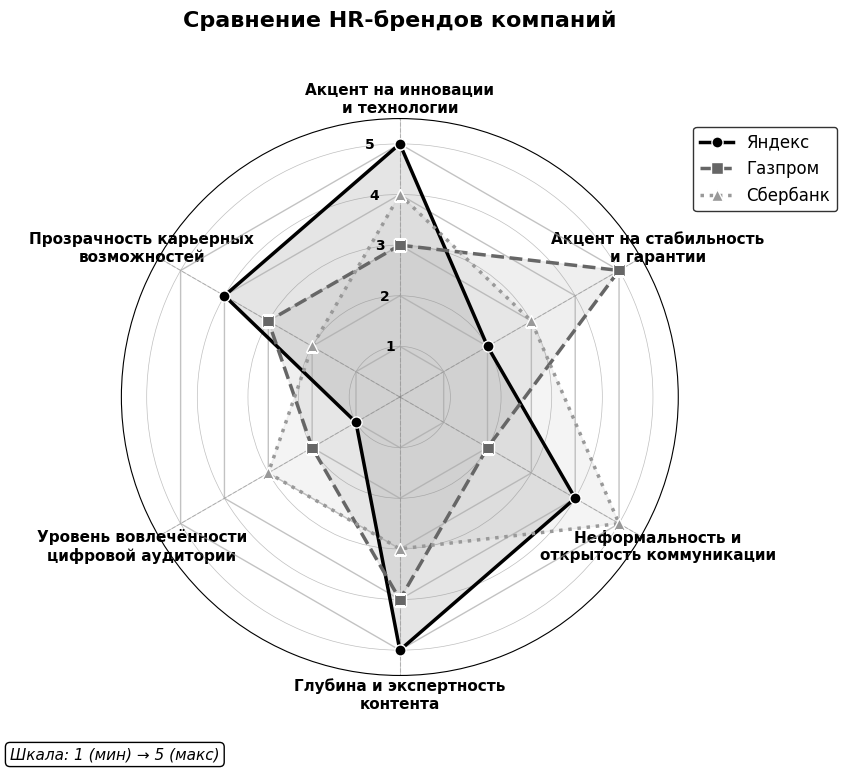

График сохранен как 'radar_chart_bw.png'


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Ваши данные
data = {
    'Яндекс': [5, 2, 4, 5, 1, 4],
    'Газпром': [3, 5, 2, 4, 2, 3],
    'Сбербанк': [4, 3, 5, 3, 3, 2]
}

categories = ['Акцент на инновации\nи технологии',
              'Акцент на стабильность\nи гарантии',
              'Неформальность и\nоткрытость коммуникации',
              'Глубина и экспертность\nконтента',
              'Уровень вовлечённости\nцифровой аудитории',
              'Прозрачность карьерных\nвозможностей']

# Настройки для чёрно-белой гаммы
colors = ['black', '#666666', '#999999']  # Разные оттенки серого
line_styles = ['-', '--', ':']  # Разные стили линий для лучшего различия
markers = ['o', 's', '^']  # Разные маркеры

# Создание радарной диаграммы
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))

# Настройка ориентации
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Настройка шкалы - делаем её хорошо видимой
ax.set_rlabel_position(30)  # Позиция подписей шкалы
ax.set_rgrids([1, 2, 3, 4, 5],  # Значения на радиальной оси
              labels=[],
              angle=22,  # Угол для подписей
              fontsize=12,
              color='black',
              weight='bold')

# Настройка линий сетки
ax.set_rorigin(0)
ax.set_rlim(0, 5.5)  # Немного увеличиваем лимит для подписей

# Основные радиальные линии (окружности)
ax.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Устанавливаем подписи категорий
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11, weight='bold', color='black')

# Добавляем радиальные линии для каждой категории
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, 5.5], '--', linewidth=0.8, color='gray', alpha=0.4)

# Добавляем круги для каждого уровня с подписями значений
for r in [1, 2, 3, 4, 5]:
    # Сама окружность
    ax.plot(angles, [r] * (N + 1), '-', linewidth=1, color='darkgray', alpha=0.7)
    # Добавляем маленькие подписи значений на окружности
    ax.text(angles[0] - 0.1, r, str(r), fontsize=10, color='black',
            ha='right', va='center', weight='bold')

# Добавляем данные для каждой компании в ч/б стиле
companies = ['Яндекс', 'Газпром', 'Сбербанк']

for i, (company, color, linestyle, marker) in enumerate(zip(companies, colors, line_styles, markers)):
    values = data[company]
    values += values[:1]  # замыкаем круг

    # Основная линия
    ax.plot(angles, values,
            linestyle=linestyle,
            linewidth=2.5,
            color=color,
            label=company,
            marker=marker,
            markersize=8,
            markerfacecolor=color,
            markeredgecolor='white',
            markeredgewidth=1)

    # Заливка с очень низкой прозрачностью для ч/б
    ax.fill(angles, values, alpha=0.1, color=color)


# Настройка легенды
legend = ax.legend(loc='upper right',
                   bbox_to_anchor=(1.3, 1.0),
                   fontsize=12,
                   frameon=True,
                   fancybox=True,
                   shadow=False,
                   edgecolor='black')

# Добавляем заголовок
plt.title('Сравнение HR-брендов компаний',
          size=16, y=1.15, weight='bold')

# Добавляем текстовое описание шкалы
ax.text(-0.2, -0.15, 'Шкала: 1 (мин) → 5 (макс)',
        transform=ax.transAxes,
        fontsize=11,
        style='italic',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))

plt.tight_layout()
plt.show()

# Сохраняем с высоким разрешением
fig.savefig('radar_chart_bw.png', dpi=300, bbox_inches='tight', facecolor='white')
print("График сохранен как 'radar_chart_bw.png'")